Using softmax run: unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch200_k3_128x_dPbins64_gn1_dpmin-700_dPmax1200
                                 mean  median
Region    Method                             
Global    Gridpoint Regression   4.92    4.91
          Model Weighting       15.02   15.17
          UNet                  27.38   27.41
Land Only Gridpoint Regression   4.94    4.63
          Model Weighting       17.68   17.37
          UNet                  26.71   26.82


/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51764/674600888.py:178: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kde_at_median = float(kde(median_val))
/var/folders/s7/mhmlfdkd1ss_n5pbssq34j780000gn/T/ipykernel_51764/674600888.py:178: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kde_at_median = float(kde(median_val))


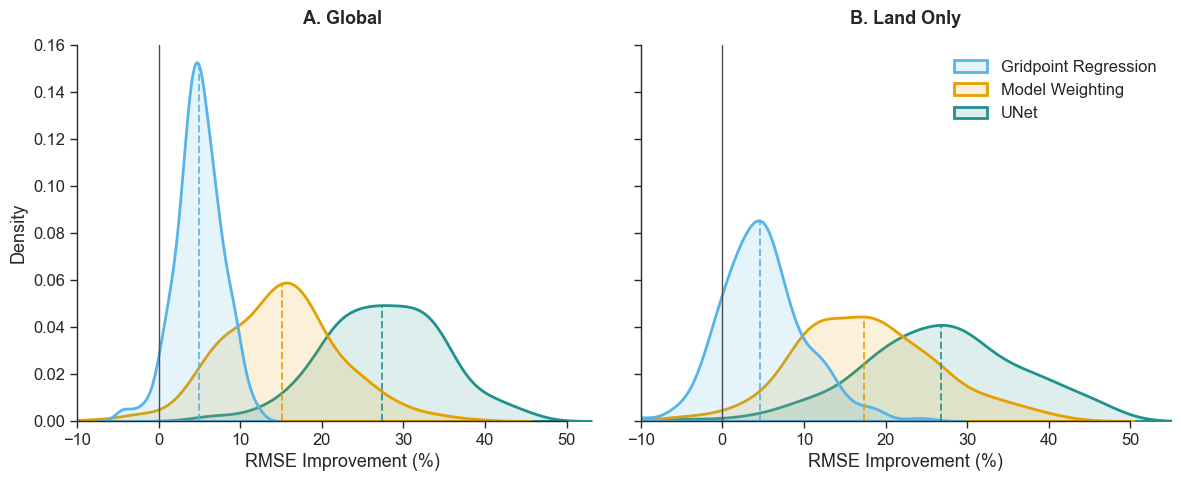

In [3]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns


# --------------------------
# Config
# --------------------------
hadgem_dir = Path("/Users/ewellmeyer/Documents/research/HadGEM")
weights_base = Path("/Users/ewellmeyer/Documents/research/weights")
requested_channel = 200
run_glob = (
    "unet_ens_HG789_PR_dPdK_Softmax_unet6R_"
    "ch*_k3_128x_dPbins64_gn1_dpmin-700_dPmax1200"
)

sns.set_context("paper", font_scale=1.35)
sns.set_style("ticks")


# --------------------------
# Helpers
# --------------------------
def extract_channel(run_name: str) -> int:
    match = re.search(r"_ch(\d+)_", run_name)
    if match is None:
        raise ValueError(f"Could not parse channel count from {run_name}")
    return int(match.group(1))


def load_softmax_run(channel: int):
    matches = []
    for run_dir in weights_base.glob(run_glob):
        if extract_channel(run_dir.name) != channel:
            continue
        arr_path = run_dir / "softmax_ensemble_analysis_arrays.npz"
        if arr_path.exists():
            matches.append(arr_path)

    if not matches:
        raise FileNotFoundError(f"No softmax analysis arrays found for channel {channel}")
    if len(matches) > 1:
        raise RuntimeError(f"Multiple softmax runs found for channel {channel}: {matches}")

    path = matches[0]
    print(f"Using softmax run: {path.parent.name}")
    return np.load(path)


def rmse_improvement(baseline_rmse, model_rmse):
    baseline_rmse = np.asarray(baseline_rmse, dtype=np.float64)
    model_rmse = np.asarray(model_rmse, dtype=np.float64)
    return (baseline_rmse - model_rmse) / (baseline_rmse + 1e-12) * 100.0


def extend_rows(rows, values, method, region):
    rows.extend(
        {
            "RMSE Improvement (%)": float(v),
            "Method": method,
            "Region": region,
        }
        for v in np.asarray(values)
    )


# --------------------------
# Load Data
# --------------------------
gweighted = np.load(hadgem_dir / "gaussian_weighted_analysis_memberwise_sig8000.npz")
polynomial = np.load(hadgem_dir / "polynomial_regression_analysis.npz")
softmax = load_softmax_run(requested_channel)

sm_test_idx = softmax["test_indices"]
sm_baseline = softmax["rmse_ppe"][sm_test_idx]
sm_baseline_land = softmax["rmse_ppe_land"][sm_test_idx]

rows = []

extend_rows(
    rows,
    rmse_improvement(
        gweighted["member_rmse_simple"][gweighted["test_idx"]],
        gweighted["member_rmse_weighted"][gweighted["test_idx"]],
    ),
    "Model Weighting",
    "Global",
)
extend_rows(
    rows,
    rmse_improvement(
        polynomial["member_rmse_mean"][polynomial["test_idx"]],
        polynomial["member_rmse_poly3"][polynomial["test_idx"]],
    ),
    "Gridpoint Regression",
    "Global",
)
extend_rows(
    rows,
    rmse_improvement(sm_baseline, softmax["rmse_softmax_mean"][sm_test_idx]),
    "UNet",
    "Global",
)

extend_rows(
    rows,
    rmse_improvement(
        gweighted["member_rmse_simple_land"][gweighted["test_idx"]],
        gweighted["member_rmse_weighted_land"][gweighted["test_idx"]],
    ),
    "Model Weighting",
    "Land Only",
)
extend_rows(
    rows,
    rmse_improvement(
        polynomial["member_rmse_mean_land"][polynomial["test_idx"]],
        polynomial["member_rmse_poly3_land"][polynomial["test_idx"]],
    ),
    "Gridpoint Regression",
    "Land Only",
)
extend_rows(
    rows,
    rmse_improvement(sm_baseline_land, softmax["rmse_softmax_mean_land"][sm_test_idx]),
    "UNet",
    "Land Only",
)

df = pd.DataFrame(rows)
method_order = ["Gridpoint Regression", "Model Weighting", "UNet"]
palette = {
    "Model Weighting": "#E69F00",
    "Gridpoint Regression": "#56B4E9",
    "UNet": sns.color_palette("viridis", n_colors=1)[0],
}

summary = (
    df.groupby(["Region", "Method"])["RMSE Improvement (%)"]
    .agg(["mean", "median"])
    .round(2)
)
print(summary)


# --------------------------
# Plot One Figure Only
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, region, letter, show_legend in zip(axes, ["Global", "Land Only"], ["A", "B"], [False, True]):
    subset = df[df["Region"] == region]

    sns.kdeplot(
        data=subset,
        x="RMSE Improvement (%)",
        hue="Method",
        hue_order=method_order,
        palette=palette,
        fill=True,
        alpha=0.15,
        linewidth=2,
        common_norm=False,
        legend=show_legend,
        ax=ax,
    )

    # Evaluate KDE at median using scipy — avoids relying on seaborn's ax.lines internals
    for method in method_order:
        values = subset.loc[subset["Method"] == method, "RMSE Improvement (%)"].values
        median_val = np.median(values)
        kde = stats.gaussian_kde(values)
        kde_at_median = float(kde(median_val))
        ax.vlines(median_val, 0, kde_at_median,
                  color=palette[method], linestyle="--", alpha=0.85, linewidth=1.4)

    ax.axvline(0, color=".3", linestyle="-", linewidth=1)
    ax.set_xlim(-10, 55)
    ax.set_ylim(0, 0.16)
    ax.set_title(f"{letter}. {region}", fontweight="bold", pad=15)
    ax.set_xlabel("RMSE Improvement (%)")
    ax.set_ylabel("Density" if region == "Global" else "")

    if show_legend:
        sns.move_legend(ax, "upper right", frameon=False, title=None)

sns.despine(trim=True)
plt.tight_layout()
plt.show()